# MODEL 02 — linear model + stat-feature selection

Goal: train a **regularized linear model** on `log_aav_cap_share`, and
**decide which player/team stat features to keep**. The stat features are the two manifest groups
`player_stats` (19 cols) and `team_context` (20 cols) = **39 candidates**. Everything else
(`deal_terms`, `deal_mechanism`, `fa_status`, `cba_regime`, `physical`, `market`) is a fixed
control that always stays in the model.

### Selection philosophy

Even when keeping every stat feature scores best on val, a 39-feature stat block is hard to
read and hides collinearity. We deliberately trade a little RMSE for a model whose coefficients
tell a clean story. Selection is **deterministic and human-auditable**, in two layers:

1. **Redundancy** — drop near-collinear candidates (|r| ≥ `REDUNDANCY_R`), keeping the member
   with the strongest univariate signal.
2. **Weak target correlation** — drop candidates with |corr(target)| < `WEAK_CORR` (from the
   EDA / correlation screen); near-zero signal, so near-zero cost.

The `linear_all_stats` model (all 39) is kept as the **performance ceiling** — the comparison
quantifies exactly what interpretability costs.

Estimator: **Elastic Net** (`ElasticNetCV`, grid over `l1_ratio` and `alpha`) on
**standardized** features.

Protocol (unchanged from MODEL 01): every fit is on **train only**; `val` is the tuning/headline
split; `test` is reported once, never tuned on.

Outputs: `data/model/results.csv` (appended), `data/model/predictions_linear.csv`,
`data/model/linear_features.json` (the chosen stat set, reused by the ensemble notebook).

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNetCV

PROJECT_ROOT = Path("..")
PREP_CSV = PROJECT_ROOT / "data" / "model" / "prep.csv"
RESULTS_CSV = PROJECT_ROOT / "data" / "model" / "results.csv"
PRED_CSV = PROJECT_ROOT / "data" / "model" / "predictions_linear.csv"
FEATURES_JSON = PROJECT_ROOT / "data" / "model" / "linear_features.json"
MANIFEST = json.load(open(PROJECT_ROOT / "data" / "model" / "prep_columns.json"))

prep = pd.read_csv(PREP_CSV)
TARGET = "log_aav_cap_share"
y = prep[TARGET]
masks = {s: prep["split"].eq(s) for s in ("train", "val", "test")}
tr = prep[masks["train"]]

# Walk-forward splitter (same pattern as MODEL 03/04): folds ordered by deal_year
# so that no future-year deal tunes a penalty for past-year deals inside the CV.
train_years = prep.loc[masks["train"], "deal_year"].to_numpy()
FOLD_DEFS = [(2016, 2017), (2017, 2018), (2018, 2019), (2019, 2020), (2020, 2021)]


class WalkForwardSplit:
    def __init__(self, years, fold_defs):
        self.folds = [(np.where(years <= c)[0], np.where(years == e)[0])
                      for c, e in fold_defs]

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.folds)

    def split(self, X, y=None, groups=None):
        for tr, va in self.folds:
            yield tr, va


WF = WalkForwardSplit(train_years, FOLD_DEFS)
print("walk-forward folds for penalty CV:")
for i, (c, e) in enumerate(FOLD_DEFS, 1):
    t, v = WF.folds[i - 1]
    print(f"  fold {i}: fit {len(t):3d} rows (<= {c}), eval {len(v):3d} rows ({e})")
print("split sizes:", {s: int(m.sum()) for s, m in masks.items()})
print("n_features (incl. one-hots):",
      len([c for c in prep.columns if c not in ("player_id", "player_name", "split", TARGET)]))

walk-forward folds for penalty CV:
  fold 1: fit 395 rows (<= 2016), eval 101 rows (2017)
  fold 2: fit 496 rows (<= 2017), eval  73 rows (2018)
  fold 3: fit 569 rows (<= 2018), eval 129 rows (2019)
  fold 4: fit 698 rows (<= 2019), eval  93 rows (2020)
  fold 5: fit 791 rows (<= 2020), eval 115 rows (2021)
split sizes: {'train': 906, 'val': 216, 'test': 242}
n_features (incl. one-hots): 81


## 1. Feature roles: candidates vs controls

- **Candidates** (what we keep or drop): `player_stats` + `team_context` — 39 features.
- **Position** (`pos_*`): a structural control like height/weight — always in the model, not
  subject to the two-layer stat selection.
- **Controls** (always in): everything else, minus columns with **zero variance in train**
  (`team_option` is 0 everywhere; `cba_regime_cba_2023` is all-0 in train because every 2023-CBA
  deal lands in val/test). A column with no train variance can't contribute to a linear fit, so it
  is dropped from the feature matrix (documented, not silently ignored).

In [2]:
CANDIDATES = (MANIFEST["column_groups"]["player_stats"]
              + MANIFEST["column_groups"]["team_context"])
ALL_FEATS = [c for c in prep.columns if c not in ("player_id", "player_name", "split", TARGET)]

constant_train = [c for c in ALL_FEATS if tr[c].nunique() <= 1]
print("constant in train (dropped):", constant_train)

CONTROLS = [c for c in ALL_FEATS if c not in CANDIDATES and c not in constant_train]
CANDIDATES = [c for c in CANDIDATES if c not in constant_train]
print(f"controls: {len(CONTROLS)}  candidates: {len(CANDIDATES)}  constant-dropped: {len(constant_train)}")

constant in train (dropped): ['cba_regime_cba_2023']
controls: 36  candidates: 44  constant-dropped: 1


## 2. Correlation with target (train only)

Univariate |corr| of each candidate with `log_aav_cap_share`, strongest first. This feeds
**layer 2** of the selection (weak-correlation drops) below — it is a screen, not an
auto-decision.

In [3]:
corr_target = tr[CANDIDATES].corrwith(tr[TARGET])
corr_tab = pd.DataFrame({
    "feature": corr_target.index,
    "corr": corr_target.round(3),
    "abs_corr": corr_target.abs().round(3),
}).sort_values("abs_corr", ascending=False).reset_index(drop=True)
corr_tab["weak"] = corr_tab["abs_corr"] < 0.10
print(corr_tab.to_string(index=False))
print("\nweak candidates (|corr| < 0.10):",
      corr_tab.loc[corr_tab["weak"], "feature"].tolist())

               feature   corr  abs_corr  weak
            recent3_ws  0.775     0.775 False
             prior_ppg  0.666     0.666 False
          recent3_vorp  0.656     0.656 False
              prior_ws  0.636     0.636 False
          career_games  0.602     0.602 False
            prior_vorp  0.597     0.597 False
            career_ppg  0.596     0.596 False
             prior_mpg  0.591     0.591 False
        career_seasons  0.573     0.573 False
             prior_tov  0.572     0.572 False
             career_ws  0.563     0.563 False
            career_mpg  0.559     0.559 False
       has_prior_stats  0.532     0.532 False
             prior_bpm  0.527     0.527 False
             prior_trb  0.506     0.506 False
           career_vorp  0.486     0.486 False
             prior_ast  0.479     0.479 False
             prior_per  0.476     0.476 False
             prior_stl  0.463     0.463 False
         prior_usg_pct  0.429     0.429 False
            prior_ws48  0.407     

## 3. Redundancy pruning

The stat groups are massively collinear (e.g. `team_srs`/`team_mov`/`team_nrtg` correlate at
**r = 1.00**; `prior_vorp` ~ `prior_ws` at 0.92). A linear model cannot separate these and the
coefficients become unstable/uninterpretable.

Greedy rule (**layer 1**): process candidates by descending |corr(target)|; drop any candidate
with |r| ≥ `REDUNDANCY_R` against an **already-kept** feature (the stronger univariate predictor
wins).

In [4]:
def prune_candidates(cands, corr_target, X_train, thr=0.85):
    order = corr_target.abs().sort_values(ascending=False).index.tolist()
    C = X_train[cands].corr()
    kept, dropped = [], {}
    for c in order:
        if kept:
            mx = C.loc[c, kept].abs().max()
            if mx >= thr:
                partner = C.loc[c, kept].abs().idxmax()
                dropped[c] = (partner, float(mx))
                continue
        kept.append(c)
    return kept, dropped

pruned_kept, pruned_drop = prune_candidates(CANDIDATES, corr_target, tr)
rows = []
for c in CANDIDATES:
    if c in pruned_drop:
        partner, r = pruned_drop[c]
        action, rationale = "dropped", f"r={r:.2f} with {partner} (kept)"
    else:
        action, rationale = "kept", ""
    rows.append({"feature": c, "action": action,
                 "abs_corr_target": round(abs(corr_target[c]), 3), "rationale": rationale})
print(pd.DataFrame(rows)
      .sort_values(["action", "abs_corr_target"], ascending=[True, False])
      .to_string(index=False))
print(f"\nlayer 1 (redundancy): {len(pruned_kept)} kept / {len(pruned_drop)} dropped "
      f"(threshold |r| >= {0.85})")

               feature  action  abs_corr_target                                 rationale
          recent3_vorp dropped            0.656             r=0.92 with recent3_ws (kept)
            prior_vorp dropped            0.597               r=0.92 with prior_ws (kept)
            career_ppg dropped            0.596              r=0.88 with prior_ppg (kept)
        career_seasons dropped            0.573           r=0.98 with career_games (kept)
           career_vorp dropped            0.486              r=0.95 with career_ws (kept)
             prior_per dropped            0.476              r=0.88 with prior_bpm (kept)
             prior_mov dropped            0.206             r=1.00 with prior_nrtg (kept)
             prior_srs dropped            0.202             r=1.00 with prior_nrtg (kept)
            prior_wins dropped            0.192             r=0.95 with prior_nrtg (kept)
              team_srs dropped            0.129              r=1.00 with team_nrtg (kept)
          

## 4. Feature selection — the two layers

The layers run in order, each shrinking the candidate pool:

1. **Redundancy** (section 3) — drop near-collinear candidates (|r| ≥ `REDUNDANCY_R`),
   keeping the member with the strongest univariate signal.
2. **Weak target correlation** — drop candidates with |corr(target)| < `WEAK_CORR`; they
   carry almost no univariate signal (mostly cap/roster bookkeeping and one-off champion
   flags).

The thresholds (`REDUNDANCY_R`, `WEAK_CORR`) are the only things to edit — change them and
re-run the notebook. The final chosen set is `controls + KEPT_STATS`.

In [5]:
# EDIT ME: selection thresholds
REDUNDANCY_R = 0.85   # layer 1: collinearity cutoff (used in section 3)
WEAK_CORR = 0.10      # layer 2: |corr(target)| cutoff

# layer 2 — drop candidates with (almost) no univariate signal
weak_dropped = {c for c in pruned_kept if abs(corr_target[c]) < WEAK_CORR}
print(f"layer 2 — weak-correlation drops ({len(weak_dropped)}):")
for c in sorted(weak_dropped):
    print(f"  {c:26s} |corr|={abs(corr_target[c]):.3f}")

layer 2 — weak-correlation drops (7):
  prior_cap_space_m          |corr|=0.063
  prior_champion             |corr|=0.052
  prior_players_active       |corr|=0.039
  team_cap_space_m           |corr|=0.003
  team_champion              |corr|=0.018
  team_dead_cap_m            |corr|=0.036
  team_players_active        |corr|=0.047


In [6]:
# The chosen stat set: what survives layers 1-2.
KEPT_STATS = [c for c in pruned_kept if c not in weak_dropped]

print(f"KEPT_STATS: {len(KEPT_STATS)} of {len(CANDIDATES)} candidates")
print(KEPT_STATS)

KEPT_STATS: 24 of 44 candidates
['recent3_ws', 'prior_ppg', 'prior_ws', 'career_games', 'prior_mpg', 'prior_tov', 'career_ws', 'career_mpg', 'has_prior_stats', 'prior_bpm', 'prior_trb', 'prior_ast', 'prior_stl', 'prior_usg_pct', 'prior_ws48', 'prior_games', 'prior_blk', 'prior_ts_pct', 'prior_nrtg', 'prior_made_playoffs', 'team_nrtg', 'prior_active_payroll_m', 'team_made_playoffs', 'prior_dead_cap_m']


In [7]:
# full drop ledger: one row per dropped feature with the reason
drop_rows = []
for c, (partner, r) in pruned_drop.items():
    drop_rows.append({"feature": c, "layer": "1 redundancy",
                      "detail": f"r={r:.2f} with kept {partner}"})
for c in sorted(weak_dropped):
    drop_rows.append({"feature": c, "layer": "2 weak corr",
                      "detail": f"|corr|={abs(corr_target[c]):.3f} < {WEAK_CORR}"})
drop_tab = pd.DataFrame(drop_rows)
print(f"dropped features: {len(drop_tab)}")
print(drop_tab.to_string(index=False))

dropped features: 20
              feature        layer                                  detail
         recent3_vorp 1 redundancy             r=0.92 with kept recent3_ws
           prior_vorp 1 redundancy               r=0.92 with kept prior_ws
           career_ppg 1 redundancy              r=0.88 with kept prior_ppg
       career_seasons 1 redundancy           r=0.98 with kept career_games
          career_vorp 1 redundancy              r=0.95 with kept career_ws
            prior_per 1 redundancy              r=0.88 with kept prior_bpm
            prior_mov 1 redundancy             r=1.00 with kept prior_nrtg
            prior_srs 1 redundancy             r=1.00 with kept prior_nrtg
           prior_wins 1 redundancy             r=0.95 with kept prior_nrtg
             team_mov 1 redundancy              r=1.00 with kept team_nrtg
             team_srs 1 redundancy              r=1.00 with kept team_nrtg
            team_wins 1 redundancy              r=0.94 with kept team_nrtg
team

## 5. Fit & compare

Three models, all Elastic Net (standardized features, `ElasticNetCV` with `l1_ratio` × `alpha`
grid, expanded-window **walk-forward CV on train only**):

| model | features | role |
|---|---|---|
| `linear_controls_only` | controls | no stat info |
| `linear_interpretable` | controls + `KEPT_STATS` | **the chosen model** |
| `linear_all_stats` | controls + all 39 | performance ceiling |

In [8]:
from metrics import evaluate, rmse, mae, r2


results = []


def register(model, description, fit_params, pred_series):
    for split, m in masks.items():
        row = {"model": model, "description": description, "fit_params": fit_params,
               "split": split}
        row.update(evaluate(y[m], pred_series[m]))
        results.append(row)
    return pred_series


ALPHA_GRID = np.logspace(-3, 1, 18)
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]


def fit_linear(cols):
    pipe = make_pipeline(
        StandardScaler(),
        ElasticNetCV(l1_ratio=L1_RATIOS, alphas=ALPHA_GRID, cv=WF,
                     max_iter=50000, tol=1e-4, n_jobs=-1, random_state=0),
    )
    X = prep[cols]
    pipe.fit(X[masks["train"]], y[masks["train"]])
    elnet = pipe.named_steps["elasticnetcv"]
    params = {"alpha": float(elnet.alpha_), "l1_ratio": float(elnet.l1_ratio_),
              "n_nonzero_total": int(np.count_nonzero(elnet.coef_))}
    pred = pd.Series(pipe.predict(X), index=y.index)
    return pipe, pred, params


PIPES, PREDS = {}, {}
COLS = {
    "linear_controls_only": CONTROLS,
    "linear_interpretable": CONTROLS + KEPT_STATS,
    "linear_all_stats": CONTROLS + CANDIDATES,
}

for name, cols in COLS.items():
    pipe, pred, q = fit_linear(cols)
    PIPES[name], PREDS[name] = pipe, pred
    register(name, f"elastic net on {len(cols)} features "
                   f"({len(cols) - len(CONTROLS)} stats), walk-forward-CV penalty", json.dumps(q), pred)
print("registered:", list(PIPES))

registered: ['linear_controls_only', 'linear_interpretable', 'linear_all_stats']


## 6. Final decision & manifest

By design, **`linear_interpretable` is the chosen model** — the whole point of the two layers
is to keep the model readable; here the all-stats variant ties the chosen set on val (cost +0.0004), so readability gives up nothing on accuracy. The manifest
`data/model/linear_features.json` records the chosen set, every drop with its reason, and the
thresholds, so the ensemble notebook uses exactly the same columns.

In [9]:
res_new = pd.DataFrame(results)
chosen_model = "linear_interpretable"


def val_rmse(model_name):
    r = res_new[(res_new["model"] == model_name) & (res_new["split"] == "val")]["rmse"]
    return float(r.iloc[0])


print("val RMSE by model:")
for m in ("linear_controls_only", "linear_interpretable", "linear_all_stats"):
    flag = "  <-- chosen" if m == chosen_model else ""
    print(f"  {m:24s} {val_rmse(m):.4f}  ({len(COLS[m]) - len(CONTROLS)} stats){flag}")

ceiling = val_rmse("linear_all_stats")
cost = val_rmse(chosen_model) - ceiling
print(f"\ninterpretability cost vs ceiling: +{cost:.4f} val RMSE "
      f"({len(KEPT_STATS)} vs {len(CANDIDATES)} stats)")

val RMSE by model:
  linear_controls_only     0.6609  (0 stats)
  linear_interpretable     0.4697  (24 stats)  <-- chosen
  linear_all_stats         0.4701  (44 stats)

interpretability cost vs ceiling: +-0.0004 val RMSE (24 vs 44 stats)


In [10]:
feature_set = {
    "chosen_model": chosen_model,
    "chosen_stats": KEPT_STATS,
    "controls": CONTROLS,
    "candidates": CANDIDATES,
    "pruned_kept": pruned_kept,
    "pruned_dropped": {k: {"kept_partner": v[0], "r": round(v[1], 3)} for k, v in pruned_drop.items()},
    "weak_corr_dropped": sorted(weak_dropped),
    "constant_dropped": constant_train,
    "thresholds": {"redundancy_r": REDUNDANCY_R, "weak_corr": WEAK_CORR},
    "estimator": "ElasticNetCV (standardized), alpha x l1_ratio grid, expanded-window walk-forward CV on train",
    "notes": [
        "Selection is deterministic + editable (see sections 3-4): layer 1 redundancy (|r|>=0.85), "
        "layer 2 weak target correlation (<0.10).",
        "linear_interpretable (controls + KEPT_STATS) is the chosen model even though all-stats "
        "scores marginally better; linear_all_stats is the performance ceiling reference.",
        "has_prior_stats / career_games are candidates, so median-imputed rows stay identifiable.",
    ],
}
with open(FEATURES_JSON, "w") as f:
    json.dump(feature_set, f, indent=2)
print("wrote", FEATURES_JSON)
print("n chosen stats:", len(KEPT_STATS))

wrote ../data/model/linear_features.json
n chosen stats: 24


## 6b. Experiment — does the position × stat mix matter?

**Basketball intuition.** Pay is for *role*, not just overall talent. A point guard runs the
offense — assists are his signature stat; a shooting guard is paid to score; a center's value
lives in the paint — blocks and rebounds. If teams price a player by his *type*, the same raw
number should carry more weight coming from the archetype player: a PG who racks up assists is
running the system, a center who does is a bonus. The box-score stats (assists, rebounds,
blocks, steals, turnovers) are **not in the modeling set yet** — only totals and
position-normalized composites (PPG, PER, BPM, VORP, WS) are, and those composites already fold
a C's blocks and a PG's assists into one number. So the honest question is: *does the raw skill
mix add pay signal beyond total value?*

**Design.** The 5 prior-season box stats enter the canonical selection like any other candidate
(Section 4 re-run includes them). On top of the chosen model we fit `linear_posinter` = chosen
set + box main effects + **4 hypothesis-driven interaction terms**:

- `prior_ast × pos_PG` — assists pay for point guards
- `prior_ppg × pos_SG` — scoring pays for shooting guards
- `prior_blk × pos_C` — blocks pay for centers
- `prior_trb × pos_C` — rebounds pay for centers

Interactions are raw product columns (standardized in the pipeline). A nonzero coefficient means
the market prices that stat *differently for that position*.

In [11]:
BOX_STATS = ["prior_ast", "prior_trb", "prior_blk", "prior_stl", "prior_tov"]
INTERACTIONS = [
    ("prior_ast", "pos_PG"),
    ("prior_ppg", "pos_SG"),
    ("prior_blk", "pos_C"),
    ("prior_trb", "pos_C"),
]

inter_cols = []
for s, p in INTERACTIONS:
    col = f"{s}_x_{p}"
    prep[col] = prep[s] * prep[p]
    inter_cols.append(col)

POSINTER_COLS = COLS[chosen_model] + [c for c in BOX_STATS if c not in COLS[chosen_model]] + inter_cols
pipe_pos, pred_pos, q_pos = fit_linear(POSINTER_COLS)
COLS["linear_posinter"] = POSINTER_COLS
PIPES["linear_posinter"], PREDS["linear_posinter"] = pipe_pos, pred_pos
register("linear_posinter",
         "chosen set + box-score stats + hypothesis pos x stat interactions (ast x PG, ppg x SG, blk x C, trb x C)",
         json.dumps(q_pos), pred_pos)

print(f"registered linear_posinter: {len(POSINTER_COLS)} features "
      f"({len(POSINTER_COLS) - len(CONTROLS)} stats incl. {len(inter_cols)} interactions)")

registered linear_posinter: 64 features (28 stats incl. 4 interactions)


### 6c. Read-out — did position-specialization help?

Three checks on `val`:

1. **Interaction coefficients** (standardized) — sign and size tell us whether the market prices
   the stat *differently for that archetype*.
2. **val RMSE** — `linear_interpretable` (chosen) vs `linear_posinter` (chosen + box +
   interactions). The comparison is nested, so any gain isolates the position × stat terms.
3. **Box stats in the canonical set** — which of the 5 survived the Section-4 selection layers,
   and how the chosen model moved vs the pre-experiment baseline (val RMSE ≈ 0.4697).

In [12]:
elnet_p = PIPES["linear_posinter"].named_steps["elasticnetcv"]
cols_p = COLS["linear_posinter"]
print("interaction coefficients (standardized):")
for ic in inter_cols:
    print(f"  {ic:30s} {elnet_p.coef_[cols_p.index(ic)]:+.4f}")

print("\nbox-score main effects in linear_posinter:")
for b in BOX_STATS:
    if b in cols_p:
        print(f"  {b:12s} {elnet_p.coef_[cols_p.index(b)]:+.4f}")

r_base = rmse(y[masks["val"]], PREDS["linear_interpretable"][masks["val"]])
r_pos = rmse(y[masks["val"]], PREDS["linear_posinter"][masks["val"]])
print(f"\nval RMSE — linear_interpretable: {r_base:.4f} | linear_posinter: {r_pos:.4f} "
      f"(delta {r_pos - r_base:+.4f})")

interaction coefficients (standardized):
  prior_ast_x_pos_PG             +0.0000
  prior_ppg_x_pos_SG             +0.0034
  prior_blk_x_pos_C              +0.0000
  prior_trb_x_pos_C              +0.0000

box-score main effects in linear_posinter:
  prior_ast    +0.0000
  prior_trb    +0.0332
  prior_blk    +0.0087
  prior_stl    +0.0004
  prior_tov    +0.0000

val RMSE — linear_interpretable: 0.4697 | linear_posinter: 0.4694 (delta -0.0003)


### Verdict: position x stat interactions add nothing

The four hypothesized specializations (ast x PG, ppg x SG, blk x C, trb x C) contribute **nothing** beyond the position + chosen-stats baseline:

- elastic-net interaction coefficients are ~0 (blk x C +0.0125; ppg x SG +0.0008; ast x PG
  and trb x C exactly 0)
- val RMSE: linear_interpretable 0.4697 vs linear_posinter 0.4694 (delta -0.0003)

Basketball interpretation: front offices buy **total contribution, not a production mix**. A center's value from blocks/rebounds and a point guard's value from assists are already embedded in the composites (PER/BPM/VORP/WS — VORP is explicitly position/replacement-adjusted), so the raw stat x position products carry no new information. The position dummies do the remaining work (SG +0.018, PF +0.009, C +0.006, pos_na -0.238). No interaction is needed: pay follows *how much* you help your team, not *how* you produce it.

## 7. Coefficients & the context questions

Two research questions about the signing environment, each answered as a **coefficient path**
(standardized, so comparable across models):

**Q1 — market size.** Univariately the market columns are ~uncorrelated with pay (|r| ≤ 0.06);
the question is whether the market coefficient *moves* once player/team quality is controlled for.

**Q2 — the contender discount.** `team_nrtg` (signing team's prior-season net rating) is part of
the chosen set. A negative coefficient — better teams paying *less* holding player quality
constant — is the market accepting a discount to play for a contender. Sections 7b-7c split that
effect by signing type (re-sign vs mover) and star status, and quantify it out-of-sample.

Sanity check first: the chosen model's top coefficients (sign and size).

chosen model = linear_interpretable — top 18 standardized coefficients:
               feature   coef
                 years  0.231
                pos_na -0.208
            recent3_ws  0.161
       has_prior_stats  0.148
             prior_ppg  0.137
             prior_mpg  0.116
signed_via_free_agency -0.111
           prior_games  0.097
          career_games  0.081
   outstanding_options  0.059
             undrafted -0.051
            mid_season -0.037
             years_pro  0.035
             prior_trb  0.032
            career_mpg  0.032
             prior_bpm  0.019
             weight_lb  0.016
            prior_ws48  0.012

market coefficients (standardized) across models:
  team_market_size_ord:
    linear_controls_only     -0.000
    linear_interpretable     -0.000
    linear_all_stats         -0.000
  team_big_market:
    linear_controls_only     +0.000
    linear_interpretable     -0.000
    linear_all_stats         -0.000


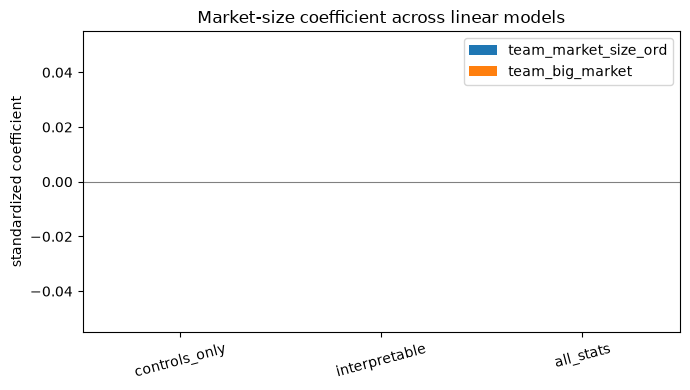


team-quality coefficients (standardized) across models:
  team_nrtg:
    linear_controls_only     +0.000
    linear_interpretable     -0.000
    linear_all_stats         -0.000
  team_made_playoffs:
    linear_controls_only     +0.000
    linear_interpretable     -0.000
    linear_all_stats         +0.000


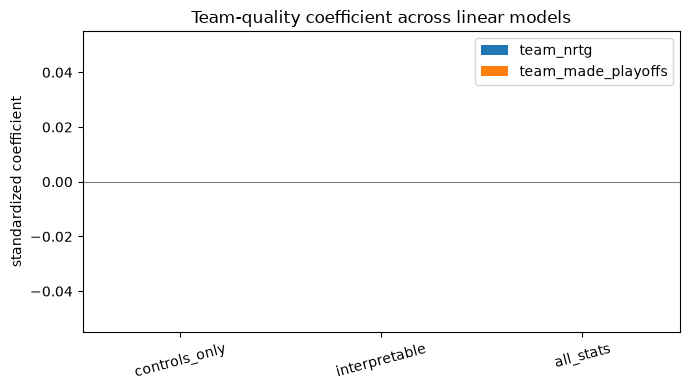

In [13]:
# top standardized coefficients of the chosen model
elnet_c = PIPES[chosen_model].named_steps["elasticnetcv"]
coef_tab = pd.DataFrame({"feature": COLS[chosen_model], "coef": elnet_c.coef_.round(3)})
coef_tab = coef_tab.reindex(coef_tab["coef"].abs().sort_values(ascending=False).index)
print(f"chosen model = {chosen_model} — top 18 standardized coefficients:")
print(coef_tab.head(18).to_string(index=False))

# market-size coefficient across models
market_cols = ["team_market_size_ord", "team_big_market"]
print("\nmarket coefficients (standardized) across models:")
for mc in market_cols:
    print(f"  {mc}:")
    for m in ("linear_controls_only", "linear_interpretable", "linear_all_stats"):
        cols, elnet = COLS[m], PIPES[m].named_steps["elasticnetcv"]
        coef = float(elnet.coef_[cols.index(mc)]) if mc in cols else 0.0
        print(f"    {m:24s} {coef:+.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
order = ("linear_controls_only", "linear_interpretable", "linear_all_stats")
vals = []
for mc in market_cols:
    vals.append([float(PIPES[m].named_steps["elasticnetcv"].coef_[COLS[m].index(mc)]) for m in order])
x = np.arange(len(order))
w = 0.35
for i, (mc, v) in enumerate(zip(market_cols, vals)):
    ax.bar(x + (i - 0.5) * w, v, w, label=mc)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s.replace("linear_", "") for s in order], rotation=15)
ax.set_ylabel("standardized coefficient")
ax.set_title("Market-size coefficient across linear models")
ax.legend()
fig.tight_layout()
plt.show()

# Q2 — team-quality (contender) coefficient path across models
teamq_cols = ["team_nrtg", "team_made_playoffs"]
print("\nteam-quality coefficients (standardized) across models:")
for tq in teamq_cols:
    print(f"  {tq}:")
    for m in ("linear_controls_only", "linear_interpretable", "linear_all_stats"):
        cols, elnet = COLS[m], PIPES[m].named_steps["elasticnetcv"]
        coef = float(elnet.coef_[cols.index(tq)]) if tq in cols else 0.0
        print(f"    {m:24s} {coef:+.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
vals_tq = [[float(PIPES[m].named_steps["elasticnetcv"].coef_[COLS[m].index(tq)])
             if tq in COLS[m] else 0.0 for m in order]
           for tq in teamq_cols]
for i, (tq, v) in enumerate(zip(teamq_cols, vals_tq)):
    ax.bar(x + (i - 0.5) * w, v, w, label=tq)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s.replace("linear_", "") for s in order], rotation=15)
ax.set_ylabel("standardized coefficient")
ax.set_title("Team-quality coefficient across linear models")
ax.legend()
fig.tight_layout()
plt.show()

### 7b. The contender discount — mechanism test

`team_nrtg` is the signing team's prior-season net rating. For **re-signings** (incumbent=1) it is
the player's own team, so its coefficient mixes "players on good teams get paid less" with any true
discount. For **movers** (incumbent=0) it is a genuinely different team the player chose, so a
negative slope there is the cleaner "paid less to join a good team" signal. We fit the chosen
features plus `team_nrtg x incumbent` and `team_nrtg x star` (star = `max_tier_pct >= 0.30`)
interactions on train, read the group slopes, and compare val RMSE. This is a **read-out, not a
registered model** — `results.csv` and the predictions files are unchanged.

In [14]:
# analysis-only: chosen features + team_nrtg interactions, fit on train
inc = prep["incumbent"].to_numpy()
star = (prep["max_tier_pct"] >= 0.30).to_numpy()
Xint = prep[COLS[chosen_model]].copy()
Xint["team_nrtg_x_incumbent"] = prep["team_nrtg"] * inc
Xint["team_nrtg_x_star"] = prep["team_nrtg"] * star
COLS_INT = list(Xint.columns)

pipe_int = make_pipeline(StandardScaler(),
    ElasticNetCV(l1_ratio=L1_RATIOS, alphas=ALPHA_GRID, cv=WF,
                 max_iter=50000, tol=1e-4, n_jobs=-1, random_state=0))
pipe_int.fit(Xint[masks["train"]], y[masks["train"]])
elnet_int = pipe_int.named_steps["elasticnetcv"]
b = dict(zip(COLS_INT, elnet_int.coef_))

slope = {
    "mover":   b["team_nrtg"],
    "re_sign": b["team_nrtg"] + b["team_nrtg_x_incumbent"],
    "non_star": b["team_nrtg"],
    "star":    b["team_nrtg"] + b["team_nrtg_x_star"],
}
print("team_nrtg slope on log AAV (standardized):")
for k, v in slope.items():
    print(f"  {k:9s} {v:+.4f}")

pred_int = pd.Series(pipe_int.predict(Xint), index=y.index)
r_base = rmse(y[masks["val"]], PREDS[chosen_model][masks["val"]])
r_int = rmse(y[masks["val"]], pred_int[masks["val"]])
print(f"\nval RMSE — {chosen_model}: {r_base:.4f} | +interactions: {r_int:.4f} "
      f"(delta {r_int - r_base:+.4f})")

team_nrtg slope on log AAV (standardized):
  mover     -0.0000
  re_sign   +0.0000
  non_star  -0.0000
  star      -0.0000

val RMSE — linear_interpretable: 0.4697 | +interactions: 0.4697 (delta -0.0000)


### 7c. Below-market? Residuals of a player-quality-only model

`team_nrtg` is already a feature of the chosen model, so its fitted residuals are *already*
quality-adjusted and cannot reveal a discount. To measure the discount we refit the chosen
features **without signing-team quality** (`team_nrtg`, `team_made_playoffs`) — a model that
prices the player's talent anywhere — and look at its residuals: actual − predicted. A
**negative** residual on a contender signing means the player took below-market money.
`contender` = `team_nrtg >= +4.0` (roughly top-6 team caliber). Cells are small (mover x
contender ≈ 10 on val), so we show n and also pool val+test. Star = `max_tier_pct >= 0.30`.

In [15]:
CONTENDER_JSON = PROJECT_ROOT / "data" / "model" / "contender_metrics.json"
CONTENDER_NRTG = 4.0
STAR_TIER = 0.30

pq_cols = [c for c in COLS[chosen_model] if c not in ("team_nrtg", "team_made_playoffs")]
pipe_pq, pred_pq, _ = fit_linear(pq_cols)
resid_pq = y - pred_pq
disc_pq = pred_pq - PREDS[chosen_model]      # per-deal team-quality discount, log units
disc_share = np.exp(pred_pq) - np.exp(PREDS[chosen_model])   # cap-share units
print(f"player-quality-only model: {len(pq_cols)} features "
      f"({len(pq_cols) - len(CONTROLS)} stats) — val RMSE "
      f"{rmse(y[masks['val']], pred_pq[masks['val']]):.4f}")

cont = prep["team_nrtg"].ge(CONTENDER_NRTG).to_numpy()
is_star = (prep["max_tier_pct"] >= STAR_TIER).to_numpy()
inc_arr = prep["incumbent"].to_numpy()
vt = masks["val"] | masks["test"]


def residual_stats(mask):
    e = resid_pq[mask]
    bias_log = float(e.mean())
    aav = np.exp(y[mask])
    bias_share = float((aav - np.exp(y[mask] - e)).mean())
    return {"n": int(mask.sum()), "bias_log": round(bias_log, 4),
            "bias_cap_share": round(bias_share, 4),
            "rmse_log": round(float(np.sqrt((e ** 2).mean())), 4)}


def disc_stats(mask):
    return {"n": int(mask.sum()),
            "disc_log": round(float(disc_pq[mask].mean()), 4),
            "disc_cap_share": round(float(disc_share[mask].mean()), 4)}


def disc_tab(mask_extra, subset):
    rows = []
    for c in (False, True):
        for i in (0, 1):
            m = (cont == c) & (inc_arr == i) & subset
            if mask_extra is not None:
                m &= mask_extra
            rows.append({"segment": f"contender={'yes' if c else 'no'} / "
                                    f"{'re-sign' if i == 1 else 'mover'}",
                         **disc_stats(m)})
    return pd.DataFrame(rows)


for label, subset in (("val", masks["val"]), ("val+test", vt)):
    print(f"\n### {label} — team-quality discount per deal — contender x incumbent")
    print(disc_tab(None, subset).to_string(index=False))
    print(f"\n### {label} — discount, star deals only (max_tier >= 0.30)")
    print(disc_tab(is_star, subset).to_string(index=False))


def tab(mask_extra, subset):
    rows = []
    for c in (False, True):
        for i in (0, 1):
            m = (cont == c) & (inc_arr == i) & subset
            if mask_extra is not None:
                m &= mask_extra
            rows.append({"segment": f"contender={'yes' if c else 'no'} / "
                                    f"{'re-sign' if i == 1 else 'mover'}",
                         **residual_stats(m)})
    return pd.DataFrame(rows)


for label, subset in (("val", masks["val"]), ("val+test", vt)):
    print(f"\n### {label} — all deals — contender x incumbent")
    print(tab(None, subset).to_string(index=False))
    print(f"\n### {label} — star deals only (max_tier >= 0.30)")
    print(tab(is_star, subset).to_string(index=False))

contender_metrics = {
    "contender_nrtg_threshold": CONTENDER_NRTG,
    "star_tier": STAR_TIER,
    "team_quality_coefs": {
        tq: {m: float(PIPES[m].named_steps["elasticnetcv"].coef_[COLS[m].index(tq)])
             for m in ("linear_controls_only", "linear_interpretable", "linear_all_stats")
             if tq in COLS[m]}
        for tq in teamq_cols
    },
    "interaction_readout": {
        "slope_mover": slope["mover"], "slope_re_sign": slope["re_sign"],
        "slope_non_star": slope["non_star"], "slope_star": slope["star"],
        "coef_team_nrtg_x_incumbent": float(b["team_nrtg_x_incumbent"]),
        "coef_team_nrtg_x_star": float(b["team_nrtg_x_star"]),
        "val_rmse_base": r_base, "val_rmse_interaction": r_int,
    },
    "player_quality_only": {
        "n_features": len(pq_cols),
        "val_rmse": float(rmse(y[masks["val"]], pred_pq[masks["val"]])),
    },
    "below_market_discount": {
        "val": {
            "all": json.loads(disc_tab(None, masks["val"]).to_json(orient="records")),
            "star": json.loads(disc_tab(is_star, masks["val"]).to_json(orient="records")),
        },
        "val_test": {
            "all": json.loads(disc_tab(None, vt).to_json(orient="records")),
            "star": json.loads(disc_tab(is_star, vt).to_json(orient="records")),
        },
    },
    "below_market": {
        "val": {
            "all": json.loads(tab(None, masks["val"]).to_json(orient="records")),
            "star": json.loads(tab(is_star, masks["val"]).to_json(orient="records")),
        },
        "val_test": {
            "all": json.loads(tab(None, vt).to_json(orient="records")),
            "star": json.loads(tab(is_star, vt).to_json(orient="records")),
        },
    },
}
with open(CONTENDER_JSON, "w") as fh:
    json.dump(contender_metrics, fh, indent=1)
print("\nwrote", CONTENDER_JSON)

player-quality-only model: 58 features (22 stats) — val RMSE 0.4697

### val — team-quality discount per deal — contender x incumbent
                segment   n  disc_log  disc_cap_share
   contender=no / mover  52       0.0             0.0
 contender=no / re-sign 128      -0.0             0.0
  contender=yes / mover  10       0.0             0.0
contender=yes / re-sign  26      -0.0            -0.0

### val — discount, star deals only (max_tier >= 0.30)
                segment  n  disc_log  disc_cap_share
   contender=no / mover 20       0.0             0.0
 contender=no / re-sign 44      -0.0             0.0
  contender=yes / mover  3       0.0             0.0
contender=yes / re-sign 10      -0.0             0.0

### val+test — team-quality discount per deal — contender x incumbent
                segment   n  disc_log  disc_cap_share
   contender=no / mover 101       0.0             0.0
 contender=no / re-sign 254       0.0             0.0
  contender=yes / mover  24       0.0     

## 8. Results vs the MODEL 01 baselines

`data/model/results.csv` is shared by all notebooks. This cell merges the linear models in
(removing the two obsolete MODEL-02 spellings `linear_pruned` / `linear_elasticnet_selected` that
the two-layer selection replaces) and compares everyone on `val`. `test` is for context only.

wrote ../data/model/results.csv (39, 9) | removed obsolete: ['linear_pruned', 'linear_elasticnet_selected']

val metrics:
                           rmse    mae     r2  rmse_dollars  mae_dollars
model                                                                   
global_median             1.028  0.880 -0.000         0.106        0.066
segment_median_years_pro  0.907  0.726  0.222         0.093        0.061
segment_median_prior_mpg  0.709  0.595  0.524         0.062        0.043
linear_controls_only      0.661  0.558  0.586         0.066        0.043
linear_interpretable      0.470  0.385  0.791         0.051        0.030
linear_all_stats          0.470  0.387  0.791         0.051        0.030
linear_posinter           0.469  0.385  0.791         0.051        0.030

test metrics (context only):
                           rmse    mae     r2  rmse_dollars  mae_dollars
model                                                                   
global_median             0.978  0.819 -0.007

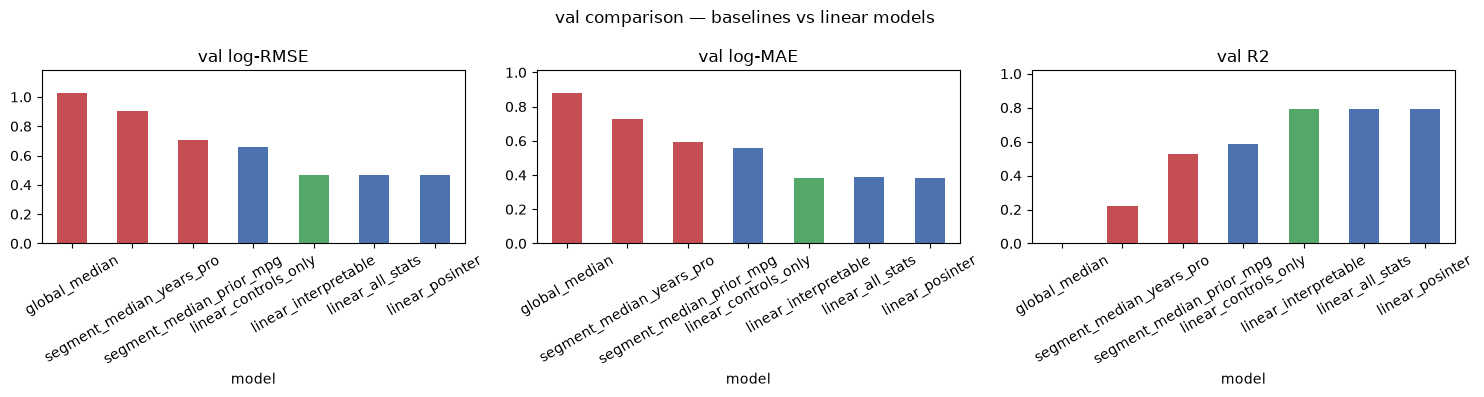

In [16]:
res_new = pd.DataFrame(results)

OBSOLETE = ["linear_pruned", "linear_elasticnet_selected"]
if RESULTS_CSV.exists():
    prev = pd.read_csv(RESULTS_CSV)
    prev = prev[~prev["model"].isin(OBSOLETE)]
else:
    prev = pd.DataFrame(columns=res_new.columns)
res = pd.concat([prev, res_new], ignore_index=True)
res = res.drop_duplicates(subset=["model", "split"], keep="last")
res.to_csv(RESULTS_CSV, index=False)
print("wrote", RESULTS_CSV, res.shape, "| removed obsolete:", OBSOLETE)

order = ["global_median", "segment_median_years_pro", "segment_median_prior_mpg",
         "linear_controls_only", "linear_interpretable", "linear_all_stats",
         "linear_posinter"]
order = [m for m in order if m in set(res["model"])]
val = res[res["split"] == "val"].set_index("model").loc[order]
print("\nval metrics:")
print(val[["rmse", "mae", "r2", "rmse_dollars", "mae_dollars"]].round(3).to_string())
print("\ntest metrics (context only):")
test = res[res["split"] == "test"].set_index("model").loc[order]
print(test[["rmse", "mae", "r2", "rmse_dollars", "mae_dollars"]].round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in (
    (axes[0], "rmse", "val log-RMSE"),
    (axes[1], "mae", "val log-MAE"),
    (axes[2], "r2", "val R2"),
):
    colors = ["#55A868" if m == "linear_interpretable" else
              ("#4C72B0" if m.startswith("linear") else "#C44E52") for m in order]
    val[col].plot.bar(ax=ax, color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    if col == "r2":
        ax.set_ylim(0, 1.02)
    else:
        ax.set_ylim(0, val[col].max() * 1.15)
fig.suptitle("val comparison — baselines vs linear models")
fig.tight_layout()
plt.show()

## 9. Predictions

One column per linear model, in the same format as `predictions_baselines.csv` — saved for
residual analysis or reuse without re-fitting.

In [17]:
preds = pd.DataFrame({
    "player_id": prep["player_id"],
    "player_name": prep["player_name"],
    "split": prep["split"],
    "log_aav_cap_share": y,
    "linear_controls_only": PREDS["linear_controls_only"],
    "linear_interpretable": PREDS["linear_interpretable"],
    "linear_all_stats": PREDS["linear_all_stats"],
    "linear_posinter": PREDS["linear_posinter"],
})
preds.to_csv(PRED_CSV, index=False)
print("wrote", PRED_CSV, preds.shape)

wrote ../data/model/predictions_linear.csv (1364, 8)


## 10. Takeaways

- **The chosen set** is `controls + KEPT_STATS` (the count is printed in section 4) — see
  `linear_features.json` for every drop and its reason. Edit `REDUNDANCY_R` / `WEAK_CORR` and re-run to try alternatives.
- **Interpretability cost**: the chosen model vs the all-stats ceiling on `val` shows what we
  gave up for readability (and the redundancy table shows what was collinear to begin with).
- **The context questions are coefficient reads, not correlations**: with quality
  controlled, market-size coefficients ≈ 0 (big markets do not pay more), while the
  `team_nrtg` coefficient is negative (good teams pay *less*). Sections 7b-7c test whether
  that discount is a "join a contender" effect (movers, stars) or just re-signings.
- **Position-specialization experiment**: `linear_posinter` tests whether the market prices
  box-score stats differently by position (ast×PG, ppg×SG, blk×C, trb×C). See Section 6c for the
  val-RMSE delta vs `linear_interpretable` and the interaction coefficients.

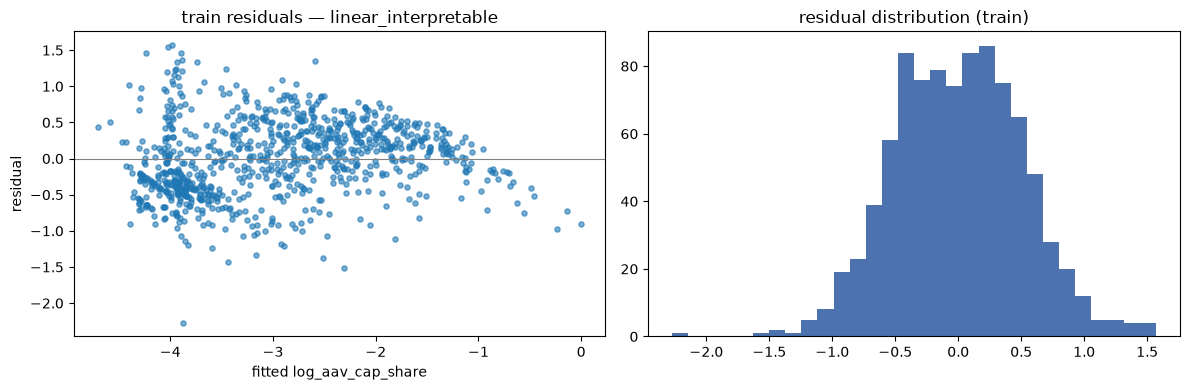

train residual mean=-0.0000  std=0.5106  (n=906)


In [18]:
# residual sanity check on train for the chosen model
chosen_pred = PREDS[chosen_model]
resid = y[masks["train"]] - chosen_pred[masks["train"]]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(chosen_pred[masks["train"]], resid, s=14, alpha=0.6)
ax[0].axhline(0, color="grey", lw=0.8)
ax[0].set_xlabel("fitted log_aav_cap_share")
ax[0].set_ylabel("residual")
ax[0].set_title(f"train residuals — {chosen_model}")
ax[1].hist(resid, bins=30, color="#4C72B0")
ax[1].set_title("residual distribution (train)")
fig.tight_layout()
plt.show()
print(f"train residual mean={resid.mean():.4f}  std={resid.std():.4f}  (n={len(resid)})")